In [1]:
import pandas as pd

In [2]:
d = pd.read_csv("Salary_Data.csv")
d

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


In [3]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [4]:
d.columns[d.isnull().any()]

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [5]:
import numpy as np

In [6]:
d["Age"]=d["Age"].fillna(d["Age"].mean())

In [7]:
d.columns[d.isnull().any()]

Index(['Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [8]:
d["Salary"]=d["Salary"].fillna(d["Salary"].mean())

In [9]:
d.columns[d.isnull().any()]

Index(['Gender', 'Education Level', 'Job Title', 'Years of Experience'], dtype='object')

In [10]:
d["Years of Experience"]=d["Years of Experience"].fillna(d["Years of Experience"].mean())

In [11]:
d["Gender"].value_counts()

Gender
Male      3674
Female    3014
Other       14
Name: count, dtype: int64

In [12]:
e=pd.get_dummies(d["Gender"])
e

,Female,Male,Other
0,False,True,False
1,True,False,False
2,False,True,False
3,True,False,False
4,False,True,False
...,...,...,...
6699,True,False,False
6700,False,True,False
6701,True,False,False
6702,False,True,False


In [13]:
d=pd.concat([d,e],axis=1)
d

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Female,Male,Other
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,False,True,False
1,28.0,Female,Master's,Data Analyst,3.0,65000.0,True,False,False
2,45.0,Male,PhD,Senior Manager,15.0,150000.0,False,True,False
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,True,False,False
4,52.0,Male,Master's,Director,20.0,200000.0,False,True,False
...,...,...,...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0,True,False,False
6700,32.0,Male,High School,Sales Associate,3.0,50000.0,False,True,False
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0,True,False,False
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0,False,True,False


In [14]:
d=d.drop(["Gender"],axis=1)
d

,Age,Education Level,Job Title,Years of Experience,Salary,Female,Male,Other
0,32.0,Bachelor's,Software Engineer,5.0,90000.0,False,True,False
1,28.0,Master's,Data Analyst,3.0,65000.0,True,False,False
2,45.0,PhD,Senior Manager,15.0,150000.0,False,True,False
3,36.0,Bachelor's,Sales Associate,7.0,60000.0,True,False,False
4,52.0,Master's,Director,20.0,200000.0,False,True,False
...,...,...,...,...,...,...,...,...
6699,49.0,PhD,Director of Marketing,20.0,200000.0,True,False,False
6700,32.0,High School,Sales Associate,3.0,50000.0,False,True,False
6701,30.0,Bachelor's Degree,Financial Manager,4.0,55000.0,True,False,False
6702,46.0,Master's Degree,Marketing Manager,14.0,140000.0,False,True,False


In [15]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6704 non-null   float64
 1   Education Level      6701 non-null   object 
 2   Job Title            6702 non-null   object 
 3   Years of Experience  6704 non-null   float64
 4   Salary               6704 non-null   float64
 5   Female               6704 non-null   bool   
 6   Male                 6704 non-null   bool   
 7   Other                6704 non-null   bool   
dtypes: bool(3), float64(3), object(2)
memory usage: 281.6+ KB


In [16]:
#pip install scikit-learn

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
x=d[["Years of Experience"]]
y=d["Salary"]

In [19]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1,random_state=0)
x_train

,Years of Experience
4753,10.0
2039,7.0
4991,7.0
2178,5.0
1771,13.0
...,...
4931,9.0
3264,2.0
1653,12.0
2607,30.0


In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
lr=LinearRegression()
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[7018.59]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Years of Experience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.869e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [22]:
y_pred=lr.predict(x_test)
y_pred

array([128876.4814982 , 149932.23741458,  72727.79905453,  79746.38435999,
       128876.4814982 , 100802.14027637,  79746.38435999,  79746.38435999,
        93783.55497091, 192043.74924733, 156950.82272004,  72727.79905453,
        86764.96966545,  86764.96966545,  93783.55497091, 135895.06680366,
       142913.65210912, 156950.82272004,  79746.38435999, 135895.06680366,
       100802.14027637, 156950.82272004, 114839.31088728,  65709.21374907,
       156950.82272004, 114839.31088728, 163969.40802549, 135895.06680366,
       135895.06680366,  65709.21374907, 170987.99333095, 114839.31088728,
        65709.21374907, 114839.31088728, 149932.23741458, 192043.74924733,
        93783.55497091, 170987.99333095, 100802.14027637, 220118.09046916,
       156950.82272004,  86764.96966545,  93783.55497091,  86764.96966545,
       142913.65210912,  79746.38435999, 170987.99333095, 185025.16394187,
        72727.79905453, 178006.57863641, 128876.4814982 , 107820.72558183,
        72727.79905453,  

In [23]:
x_test

,Years of Experience
119,10.0
2805,13.0
3709,2.0
4762,3.0
98,10.0
...,...
5684,11.0
3435,3.0
130,21.0
302,9.0


In [24]:
lr.coef_

array([7018.58530546])

In [25]:
lr.intercept_

np.float64(58690.628443616464)

In [26]:
from sklearn.metrics import r2_score

In [27]:
r2_score(y_test,y_pred)

0.6693988200498641

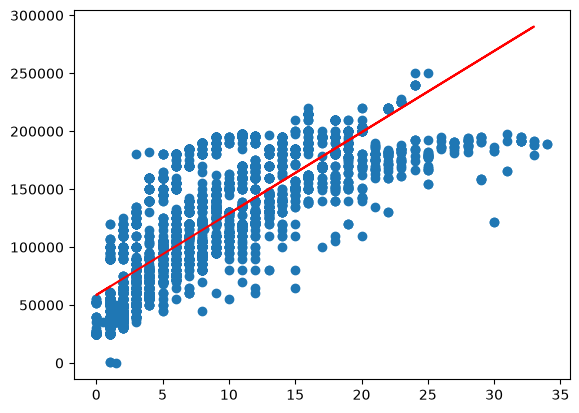

In [28]:
import matplotlib.pyplot as plt

plt.scatter(x_train,y_train)
plt.plot(x_test,y_pred,color="red")
plt.show()

In [29]:
import numpy as np

i=np.array([4,8]).reshape(-1,1)
n=lr.predict(i)
n

C:\Users\gavas\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 86764.96966545, 114839.31088728])